# Parte 1: ANOVA

__Dataset__: exams.csv de ejercicios anteriores.

__Objetivo__: Identificar qué factores influyen realmente en el rendimiento académico y cuáles no tienen un impacto estadísticamente significativo.

Calcula y añade al DF la nota media de las tres asignaturas (math, reading, writing) y realiza un análisis ANOVA con cada variable categórica que tenga 3 o más grupos dentro de la variable.

Realiza los análisis en celdas diferentes para cada variable categórica:

+ Visualización: Crea un Boxplot para visualizar el rendimiento por categoría. (cada box es un grupo dentro de la variable, ordenados de menor a mayor media, el eje Y es la nota media) 
+ Estadística: En celda aparte a la visualización, ejecuta el ANOVA y el test de Tukey y muestra las tablas.
+ Analiza: Comenta de forma conjunta los boxplots y ANOVA para cada variable.
+ Responde: ¿Existen diferencias significativas en las categorías de las variables analizadas? ¿Dentro cada variable, entre qué grupos específicos existe la mayor brecha de rendimiento (diferencia de nota media)?

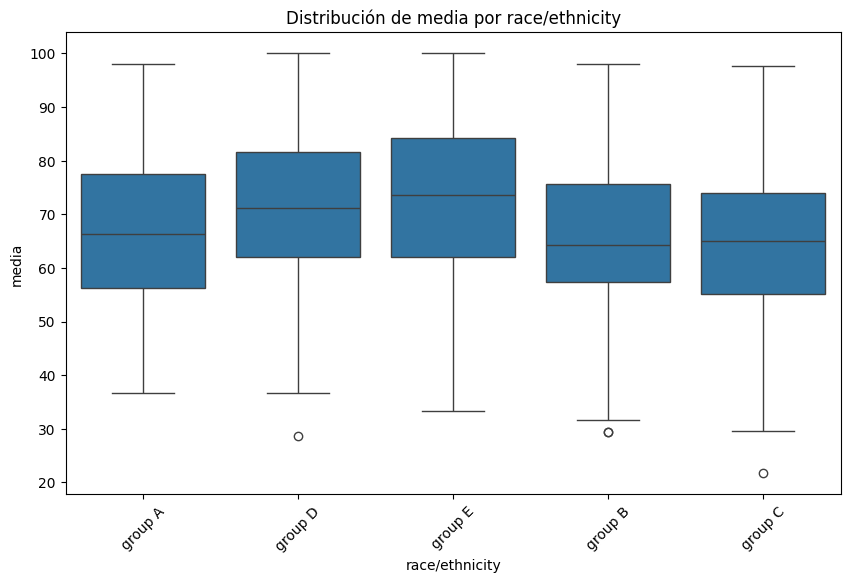

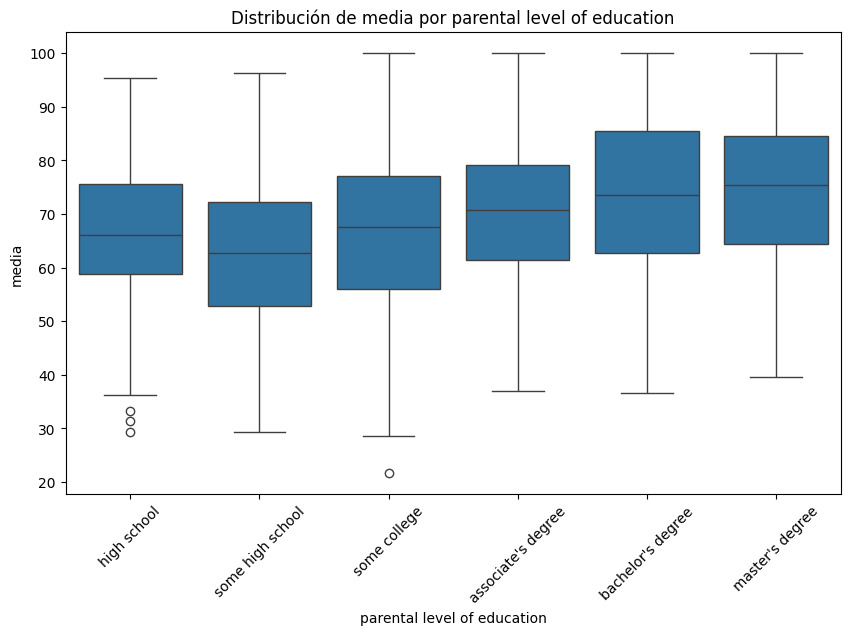

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dfexams = pd.read_csv("exams.csv")
dfexams['media'] = round((dfexams['math score'] + dfexams['reading score'] + dfexams['writing score'])/3,2)
for a in ['race/ethnicity', 'parental level of education']:
    plt.figure(figsize=(10, 6)) # Opcional: ajusta el tamaño para que se lea mejor
    sns.boxplot(data=dfexams, x=a, y="media")
    plt.title(f"Distribución de media por {a}")
    plt.xticks(rotation=45) # Útil para que los nombres largos no se choquen
    plt.show()


In [13]:
#ANOVA
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=dfexams['media'], groups=dfexams['race/ethnicity'], alpha=0.05)
print(tukey.summary())


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
group A group B  -1.5794 0.9178 -6.7126  3.5538  False
group A group C  -2.2369  0.718 -7.1023  2.6285  False
group A group D   4.2887 0.1286 -0.6868  9.2641  False
group A group E   5.4863 0.0524 -0.0354 11.0081  False
group B group C  -0.6575 0.9855 -4.1189   2.804  False
group B group D   5.8681 0.0001  2.2536  9.4826   True
group B group E   7.0658 0.0001  2.7299 11.4016   True
group C group D   6.5255    0.0  3.3027  9.7484   True
group C group E   7.7232    0.0   3.708 11.7384   True
group D group E   1.1977 0.9338 -2.9502  5.3456  False
------------------------------------------------------


In [14]:
tukey = pairwise_tukeyhsd(endog=dfexams['media'], groups=dfexams['parental level of education'], alpha=0.05)
print(tukey.summary())

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree    3.092 0.4227  -1.6345  7.8185  False
associate's degree       high school  -4.3934 0.0212  -8.3841 -0.4027   True
associate's degree   master's degree   4.0887 0.2893  -1.4771  9.6544  False
associate's degree      some college  -3.5196 0.1039  -7.4191    0.38  False
associate's degree  some high school  -7.6621    0.0   -11.71 -3.6143   True
 bachelor's degree       high school  -7.4854 0.0001  -12.216 -2.7547   True
 bachelor's degree   master's degree   0.9967 0.9973  -5.1215  7.1148  False
 bachelor's degree      some college  -6.6115 0.0008 -11.2656 -1.9575   True
 bachelor's degree  some high school -10.7541    0.0 -15.5331 -5.9751   True
       high school   master's degree   8.4821 0.0002   2.9127 14.0514   True

**¿Existen diferencias significativas en las categorías de las variables analizadas?**

-Entre la etnia existe mayor diferencia que entre la educacion de los padres

**¿Dentro cada variable, entre qué grupos específicos existe la mayor brecha de rendimiento (diferencia de nota media)?**

-race ethnity:La mayor diferencia es entre el grupo C y E

-parental level of education: la mayor diferencia es entre master's degree y some high school


# Parte 2: Series Temporales

__Dataset__: Netflix Stock Price Prediction https://www.kaggle.com/datasets/jainilcoder/netflix-stock-price-prediction

__Objetivo__: Aprender a limpiar, transformar y suavizar datos temporales para identificar tendencias.

## Procesamiento y Suavizado (cada punto en celda independiente)
+ Preparación: Carga el dataset, convierte la columna de fecha a datetime y establécela como índice.
+ Filtrado: Selecciona únicamente los datos correspondientes a los últimos 2 años del dataset con un slice.
    + `fecha_final = df.index.max()` Obtenemos la marca de tiempo máxima
    + `fecha_inicial = fecha_final - pd.DateOffset(years=2)` restamos 2 años para obtener el valor inicial del rango
    + A partir de fecha_inicial y fecha_incial hacemos slice
+ Gráfica 1:
    + Grafica el precio de cierre (Close) original.
    + Calcula y superpone en el mismo gráfico una media móvil de 7 días (corto plazo) y una de 30 días (largo plazo).
+ Gráfica 2:
    + Utiliza resample('ME').mean() para mostrar un gráfico de __barras__ con el precio promedio de cada mes. El eje X es el tiempo (formatea para que solo se vea el mes y año). El eje Y es el promedio del precio de la acción de cada mes. 

## Interpretación
+ ¿En qué periodos la media móvil de 7 días cruza a la de 30 hacia arriba? (Esto suele indicar una tendencia alcista).
+ Observando el gráfico de "Resample" mensual: ¿Existe alguna estacionalidad? Es decir, ¿hay meses donde la acción siempre parece bajar o subir?, observar patrones repetitivos.

In [18]:
import datetime

df_netflix = pd.read_csv('NFLX.csv')
df_netflix['Date'] = pd.to_datetime(df_netflix['Date'])
df_netflix.set_index('Date', inplace=True)

fecha_final = df_netflix.index.max()
fecha_inicial = fecha_final - pd.DateOffset(years=2)

df_netflix_fil = df_netflix.loc[fecha_inicial:fecha_final]
df_netflix_fil.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-02-04,361.000000,369.570007,356.100006,369.010010,369.010010,7161500
2020-02-05,375.130005,375.250000,362.299988,369.670013,369.670013,6437000
2020-02-06,369.600006,371.549988,362.510010,366.950012,366.950012,3920400
2020-02-07,365.040009,371.799988,363.570007,366.769989,366.769989,4385200
2020-02-10,365.000000,374.799988,362.519989,371.070007,371.070007,5294100


<function matplotlib.pyplot.show(close=None, block=None)>

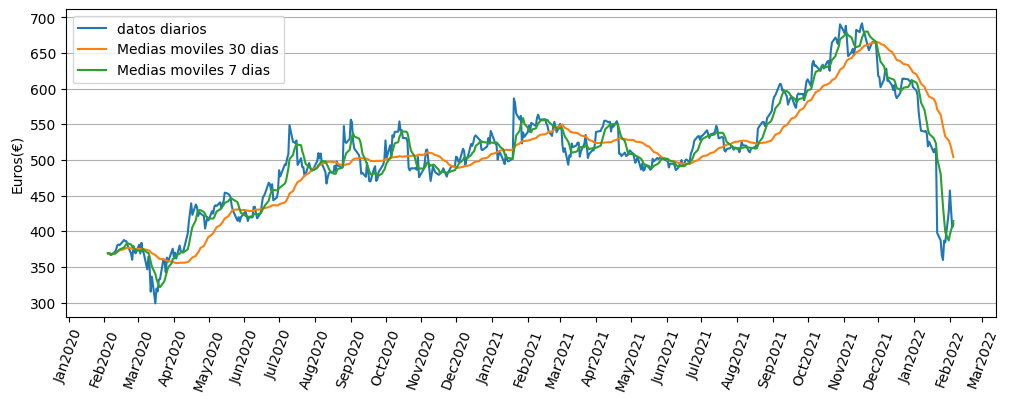

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize = (12,4))
plt.plot(df_netflix_fil['Close'], label="datos diarios")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b%Y'))
plt.xticks(rotation=70)

cierre_moviles_30 = df_netflix_fil['Close'].rolling(window= 30, min_periods = 1).mean()
plt.plot(cierre_moviles_30, label="Medias moviles 30 dias")

cierre_moviles_30 = df_netflix_fil['Close'].rolling(window= 7, min_periods = 1).mean()
plt.plot(cierre_moviles_30, label="Medias moviles 7 dias")

plt.legend()
plt.grid(axis='y')
plt.ylabel("Euros(€)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

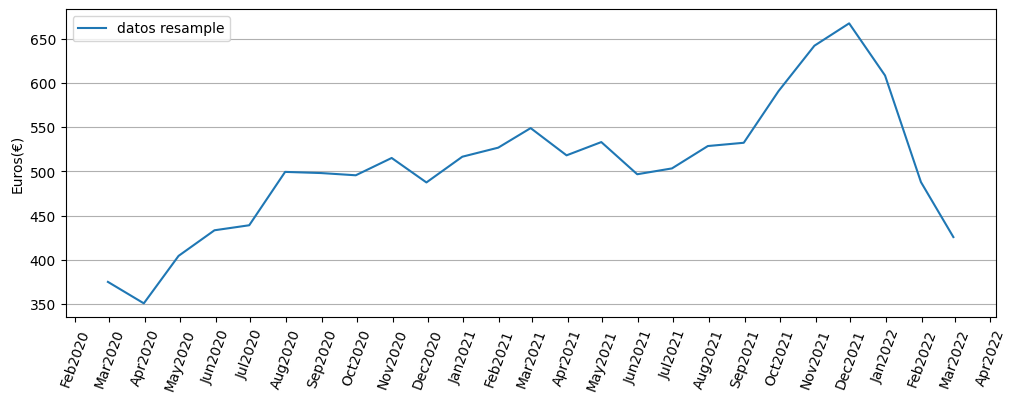

In [27]:
df_netflix_resample = df_netflix_fil.resample('ME').mean()
plt.figure(figsize = (12,4))
plt.plot(df_netflix_resample['Close'], label="datos resample")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b%Y'))
plt.xticks(rotation=70)
plt.legend()
plt.grid(axis='y')
plt.ylabel("Euros(€)")
plt.show

**¿En qué periodos la media móvil de 7 días cruza a la de 30 hacia arriba? (Esto suele indicar una tendencia alcista).**

+Marzo 2020
+Junio 2020
+Agosto 2020
+Octubre 2020
+Febrero 2021
+Abril 2021
+Agosto 2021

**Observando el gráfico de "Resample" mensual: ¿Existe alguna estacionalidad? Es decir, ¿hay meses donde la acción siempre parece bajar o subir?, observar patrones repetitivos.**

+Entre agosto y octubre de 2020